# Embedding predictions of ogbn network classes

In this file I will focus on making class predictions through the use of node_feature embedding space.

The embedding vectors have a dimension of 128, and there are about 170k nodes in total.

## Imports and dataset download

In [ ]:
!pip install ogb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from ogb.nodeproppred import NodePropPredDataset
import numpy as np
import torch

In [ ]:
import torch

# Save original torch.load function
_torch_load_func = torch.load

# Define a wrapper that forces weights_only=False
def custom_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _torch_load_func(*args, **kwargs)

# Monkey-patch torch.load to use our custom wrapper
torch.load = custom_torch_load

# Initialize the dataset (NodePropPredDataset is imported in a previous cell)
dataset = NodePropPredDataset(name='ogbn-arxiv')
graph, y = dataset[0]

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:01<00:00, 75.04it/s]


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 12633.45it/s]

Saving...


In [ ]:
y = y.squeeze()
y

array([ 4,  5, 28, ..., 10,  4,  1])

In [ ]:
len(np.where(graph["node_year"] == 2017)[0])

21442

In [ ]:
len(np.where(graph["node_year"] == 2018)[0])

29799

In [ ]:
len(np.where(graph["node_year"] == 2019)[0])

39711

In [ ]:
graph["node_feat"]

array([[-0.057943, -0.05253 , -0.072603, ...,  0.173364, -0.172796,
        -0.140059],
       [-0.1245  , -0.070665, -0.325202, ...,  0.068524, -0.372111,
        -0.301036],
       [-0.080242, -0.023328, -0.183787, ...,  0.109919,  0.117589,
        -0.139883],
       ...,
       [-0.22053 , -0.036568, -0.402199, ...,  0.11336 , -0.161393,
        -0.145171],
       [-0.138236,  0.040885, -0.251811, ..., -0.08929 , -0.041253,
        -0.376132],
       [-0.029875,  0.268417, -0.161124, ...,  0.120807,  0.077647,
        -0.091018]], dtype=float32)

In [ ]:
split_idx = dataset.get_idx_split()

train_idx = split_idx["train"]

In [ ]:
len(train_idx)

90941

In [ ]:
test_idx = split_idx["test"]

In [ ]:
test_idx[0]

np.int64(346)

In [ ]:
len(test_idx)

48603

In [ ]:
valid_idx = split_idx["valid"]

/tmp/ipykernel_887/1144259599.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_names, y=split_lengths, palette='viridis')


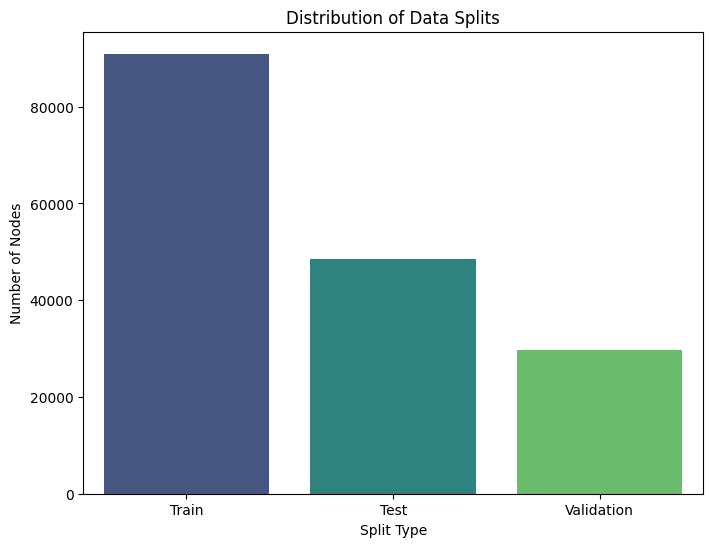

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

split_names = ['Train', 'Test', 'Validation']
split_lengths = [len(train_idx), len(test_idx), len(valid_idx)]

plt.figure(figsize=(8, 6))
sns.barplot(x=split_names, y=split_lengths, palette='viridis')
plt.title('Distribution of Data Splits')
plt.ylabel('Number of Nodes')
plt.xlabel('Split Type')
plt.show()

get centroids of all classes

That means go through each class and its nodes, get the node_features and compute mean

In [ ]:
cls_indexes = []
for cls in range(40):
  cls_indexes.append(np.where(y == cls)[0])

In [ ]:
cls_indexes[2]

array([    43,     79,    110, ..., 169111, 169302, 169315])

## Compute centroids on the entire train dataset

Get all features from `cls_indexes[x]` and compute mean

In [ ]:
centroids = []
for cls, indexes in enumerate(cls_indexes):
  centroids.append(graph["node_feat"][indexes].mean(axis=0))


In [ ]:
centroids[0]

array([-0.08344597, -0.01832454, -0.21693629, -0.10920637,  0.02322552,
       -0.04646448, -0.39856356, -0.13793719,  0.00313103,  0.14164943,
       -0.06879787, -0.47172636,  0.15345055,  0.03252691, -0.20918609,
        0.04877224,  0.10530245,  0.43524104,  0.00213274, -0.19870794,
       -0.26638135,  0.21643046, -0.28756952,  0.06531173, -0.14859931,
        0.3776644 ,  0.07981879, -0.39428833,  0.0315932 ,  0.00891967,
       -0.09397177,  0.09271468, -0.08307739,  0.07854996, -0.00924365,
       -0.28972843, -0.10235976,  0.07824453,  0.11052133,  0.21274708,
        0.2284355 , -0.14059733,  0.15880881, -0.09098744,  0.11548962,
        0.0987733 ,  0.25682434, -0.04055779,  0.3263117 ,  0.12785828,
        0.29353216,  0.13361388, -0.09911864, -0.10702757, -0.12154882,
        0.04354135, -0.08090022, -0.0408359 , -0.00113526, -0.05026219,
        0.4231157 ,  0.04613413,  0.10808315, -0.02365121, -0.01431668,
        0.33283108, -0.23046419, -0.02567738,  0.3877431 , -0.38

Technically we could change the centroid computation to a weighted one, defined by how many edges a node has compared to the others.

The weighted centroid $\mathbf{c}$ of a set of embedding vectors $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_n\}$ corresponding to nodes with degrees $\{d_1, d_2, \dots, d_n\}$ is defined as:

$$\mathbf{c} = \frac{\sum_{i=1}^{n} d_i \mathbf{v}_i}{\sum_{i=1}^{n} d_i}$$

In [ ]:
for node in test_idx:
  node_features = graph["node_feat"][node]

  dot_products = np.dot(centroids, node_features)
  node_features_norm = np.linalg.norm(node_features)

  centroid_norms = np.linalg.norm(centroids, axis=1)
  similarities = dot_products / (node_features_norm * centroid_norms)
  print(similarities.argmax())
  break

10


In [ ]:
# Evaluate accuracy on the test set using the centroids
preds = []

centroids_arr = np.array(centroids)
centroid_norms = np.linalg.norm(centroids_arr, axis=1)

for node in test_idx:
    node_feat = graph["node_feat"][node]

    # Vectorized cosine similarity
    dot = np.dot(centroids_arr, node_feat)
    node_norm = np.linalg.norm(node_feat)
    sims = dot / (node_norm * centroid_norms)

    preds.append(sims.argmax())

# Calculate accuracy
correct = (np.array(preds) == y[test_idx])
accuracy = correct.mean()
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.3338


In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

In [ ]:
y_true = y[test_idx]

nmi = normalized_mutual_info_score(y_true, preds)
ari = adjusted_rand_score(y_true, preds)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2550
ARI: 0.1480


Note that this was not done through few-shot! centroids were computed as a mean of all the train nodes for each class, without care for their degree or possible weights.

## Weighted centroid predictions

In [ ]:
# edge_index has shape [2, num_edges]. edge_index[0] contains source nodes.
num_nodes = graph['num_nodes']
edge_index = graph['edge_index']

# Compute out-degree for each node
degrees = np.zeros(num_nodes)
sources, counts = np.unique(edge_index[0], return_counts=True)
degrees[sources] = counts

# To avoid division by zero and give isolated nodes some weight, we can use (degree + 1)
weights = degrees + 1

# Compute Weighted Centroids
weighted_centroids = []
for cls, indexes in enumerate(cls_indexes):
    cls_feats = graph["node_feat"][indexes]
    cls_weights = weights[indexes].reshape(-1, 1)

    weighted_avg = np.sum(cls_feats * cls_weights, axis=0) / np.sum(cls_weights)
    weighted_centroids.append(weighted_avg)

weighted_centroids_arr = np.array(weighted_centroids)

In [ ]:
# Evaluate accuracy with Weighted Centroids
w_preds = []
w_centroid_norms = np.linalg.norm(weighted_centroids_arr, axis=1)

for node in test_idx:
    node_feat = graph["node_feat"][node]
    dot = np.dot(weighted_centroids_arr, node_feat)
    node_norm = np.linalg.norm(node_feat)
    sims = dot / (node_norm * w_centroid_norms)
    w_preds.append(sims.argmax())

w_accuracy = (np.array(w_preds) == y[test_idx]).mean()
print(f"Weighted Centroid Test Accuracy: {w_accuracy:.4f}")
print(f"Improvement: {w_accuracy - accuracy:.4f}")

Weighted Centroid Test Accuracy: 0.3047
Improvement: -0.0291


In [ ]:
y_true = y[test_idx]

nmi = normalized_mutual_info_score(y_true, w_preds)
ari = adjusted_rand_score(y_true, w_preds)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2510
ARI: 0.1221


This suggests that in the dataset, a node's 'influence' doesn't necessarily make its features more representative of its class's center. In fact, highly cited papers or papers with many references might have more 'general' or interdisciplinary language, which could pull the centroid away from the specific feature clusters of that category.

## Few-shot centroid predictions

In [ ]:
centroids = []
for cls, indexes in enumerate(cls_indexes):
  centroids.append(graph["node_feat"][np.random.choice(indexes, 16)].mean(axis=0))

In [ ]:
for node in test_idx:
  node_features = graph["node_feat"][node]

  dot_products = np.dot(centroids, node_features)
  node_features_norm = np.linalg.norm(node_features)

  centroid_norms = np.linalg.norm(centroids, axis=1)
  similarities = dot_products / (node_features_norm * centroid_norms)
  print(similarities.argmax())
  break

30


In [ ]:
# Evaluate accuracy on the test set using the centroids
preds = []

# Converting centroids to a numpy array for vectorized computation
centroids_arr = np.array(centroids)
centroid_norms = np.linalg.norm(centroids_arr, axis=1)

# We'll check a subset or the whole test set
for node in test_idx:
    node_feat = graph["node_feat"][node]

    # Vectorized cosine similarity
    dot = np.dot(centroids_arr, node_feat)
    node_norm = np.linalg.norm(node_feat)
    sims = dot / (node_norm * centroid_norms)

    preds.append(sims.argmax())

# Calculate accuracy
correct = (np.array(preds) == y[test_idx])
accuracy = correct.mean()
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.2952


In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

In [ ]:
y_true = y[test_idx]

nmi = normalized_mutual_info_score(y_true, preds)
ari = adjusted_rand_score(y_true, preds)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2210
ARI: 0.1268


With using the few-shot method, our accuracy drops below 29%.

## Deep Learning experimentation

Below are some tests for using DL models for prediction of classes using the embedding space.

The idea is that NNs can learn way more complex shapes.

### Imports

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
from keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_history(history):
  plt.figure()
  for key in history.history.keys():
    plt.plot(history.epoch, history.history[key], label=key)
  plt.legend()
  plt.tight_layout()

### Simple MLP Classifier

In [ ]:
# 1. Prepare Data
X_train = torch.tensor(graph["node_feat"][train_idx], dtype=torch.float32)
y_train = torch.tensor(y[train_idx], dtype=torch.long)
X_test = torch.tensor(graph["node_feat"][test_idx], dtype=torch.float32)
y_test = torch.tensor(y[test_idx], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=512, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=512, shuffle=False)

# 2. Define a Simple MLP
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLPClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLPClassifier(input_dim=128, hidden_dim=256, num_classes=40).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 3. Training Loop
model.train()
for epoch in range(10):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        out = model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# 4. Evaluation
model.eval()
correct = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        preds = model(batch_x).argmax(dim=1)
        correct += (preds == batch_y).sum().item()

dl_accuracy = correct / len(test_idx)
print(f"\nDeep Learning (MLP) Test Accuracy: {dl_accuracy:.4f}")

Epoch 1, Loss: 1.9472
Epoch 2, Loss: 1.6794
Epoch 3, Loss: 1.6381
Epoch 4, Loss: 1.6136
Epoch 5, Loss: 1.5960
Epoch 6, Loss: 1.5763
Epoch 7, Loss: 1.5661
Epoch 8, Loss: 1.5547
Epoch 9, Loss: 1.5489
Epoch 10, Loss: 1.5428

Deep Learning (MLP) Test Accuracy: 0.5415


### Basic Perceptron

In [ ]:
model = keras.Sequential([
    keras.layers.Input((128,)),
    keras.layers.Dense(256),
    keras.layers.ReLU(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(40)
])
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,304 (169.16 KB)

 Trainable params: 43,304 (169.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(graph["node_feat"][train_idx], y[train_idx], epochs=5, batch_size=256)

Epoch 1/5
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2631 - loss: 4.7871
Epoch 2/5
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2750 - loss: 4.3897
Epoch 3/5
356/356 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2530 - loss: 4.4391
Epoch 4/5
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2524 - loss: 4.3709
Epoch 5/5
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1148 - loss: 4.4794


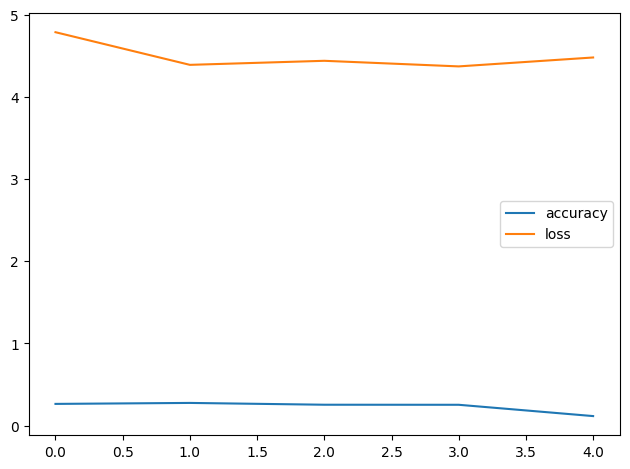

In [ ]:
plot_history(history)

In [ ]:
loss, acc = model.evaluate(graph["node_feat"][test_idx], y[test_idx], verbose=0)

In [ ]:
acc

0.22052136063575745

### Perceptron with an additional Dense layer

In [ ]:
model = keras.Sequential([
    keras.layers.Input((128,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(40, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,080 (277.66 KB)

 Trainable params: 71,080 (277.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    graph["node_feat"][train_idx],
    y[train_idx],
    validation_data = (graph["node_feat"][valid_idx], y[valid_idx]),
    epochs=20,
    batch_size=512,
)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.4923 - loss: 1.7861 - val_accuracy: 0.5300 - val_loss: 1.6374
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5137 - loss: 1.6984 - val_accuracy: 0.5411 - val_loss: 1.5885
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5223 - loss: 1.6552 - val_accuracy: 0.5384 - val_loss: 1.5711
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5311 - loss: 1.6250 - val_accuracy: 0.5441 - val_loss: 1.5519
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5355 - loss: 1.6021 - val_accuracy: 0.5477 - val_loss: 1.5430
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5412 - loss: 1.5819 - val_accuracy: 0.5511 - val_loss: 1.5318
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5446 - loss: 1.5657 - val_accuracy: 0.5557 - val_loss: 1.5260
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5485 - loss: 1.5519 - val_accu

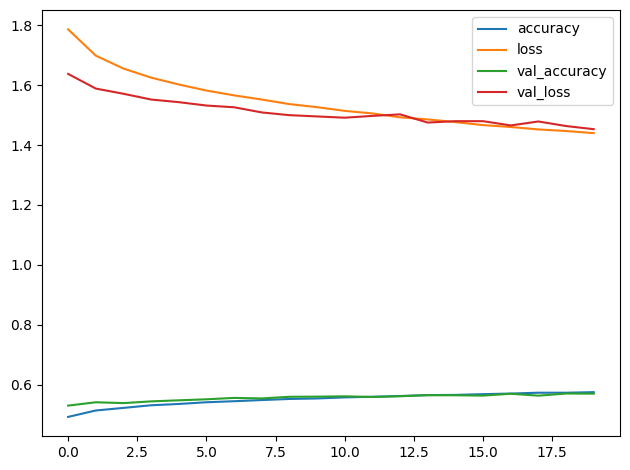

In [ ]:
plot_history(history)

In [ ]:
loss, acc = model.evaluate(graph["node_feat"][test_idx], y[test_idx], verbose=0)
acc

0.5479908585548401

In [ ]:
preds = model.predict(graph["node_feat"][test_idx])

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [ ]:
predicted_labels = np.argmax(preds, axis=1)
nmi = normalized_mutual_info_score(y[test_idx], predicted_labels)
ari = adjusted_rand_score(y[test_idx], predicted_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.3525
ARI: 0.3551


In [ ]:
preds = model.predict(graph["node_feat"])
predicted_labels = np.argmax(preds, axis=1)
nmi = normalized_mutual_info_score(y, predicted_labels)
ari = adjusted_rand_score(y, predicted_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

5292/5292 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
NMI: 0.3997
ARI: 0.4170


### Little more complex Perceptron

In [ ]:
model = models.Sequential([
    # Input Layer explicitly defining your 128d vector
    layers.InputLayer(input_shape=(128,)),

    # First Hidden Block
    # We project the 128d vector into a higher-dimensional space to find complex boundaries
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4), # Aggressive dropout since dense embeddings are prone to overfitting

    # Second Hidden Block
    # Compress back down to learn the most salient class features
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output Layer
    # For binary classification (2 classes): use Dense(1, activation='sigmoid')
    layers.Dense(40, activation='softmax')
])

# Compile the model
# Use 'binary_crossentropy' if doing binary classification
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,616 (283.66 KB)

 Trainable params: 71,848 (280.66 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
history = model.fit(
    graph["node_feat"][train_idx],
    y[train_idx],
    validation_data = (graph["node_feat"][valid_idx], y[valid_idx]),
    epochs=20,
    batch_size=512,
)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3961 - loss: 2.3646 - val_accuracy: 0.4025 - val_loss: 2.3130
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4794 - loss: 1.8746 - val_accuracy: 0.5161 - val_loss: 1.7993
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4975 - loss: 1.7798 - val_accuracy: 0.5401 - val_loss: 1.5944
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5053 - loss: 1.7247 - val_accuracy: 0.5441 - val_loss: 1.5534
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5142 - loss: 1.6930 - val_accuracy: 0.5567 - val_loss: 1.5229
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5188 - loss: 1.6676 - val_accuracy: 0.5485 - val_loss: 1.5287
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5249 - loss: 1.6490 - val_accuracy: 0.5524 - val_loss: 1.5223
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5252 - loss: 1.6316 - val_accu

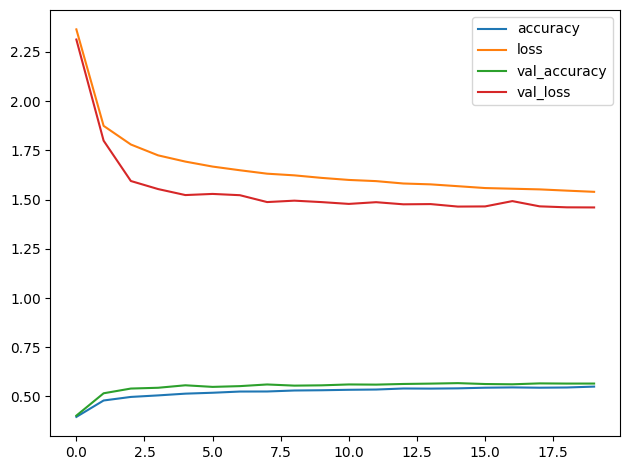

In [ ]:
plot_history(history)

In [ ]:
preds = model.predict(graph["node_feat"][test_idx])
predicted_labels = np.argmax(preds, axis=1)
nmi = normalized_mutual_info_score(y[test_idx], predicted_labels)
ari = adjusted_rand_score(y[test_idx], predicted_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
NMI: 0.3481
ARI: 0.3553


In [ ]:
preds = model.predict(graph["node_feat"])
predicted_labels = np.argmax(preds, axis=1)
nmi = normalized_mutual_info_score(y, predicted_labels)
ari = adjusted_rand_score(y, predicted_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

5292/5292 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
NMI: 0.3947
ARI: 0.4120


### Tweaked dropout complex perceptron

In [ ]:
model = models.Sequential([
    # Input Layer explicitly defining your 128d vector
    layers.InputLayer(input_shape=(128,)),

    # First Hidden Block
    # We project the 128d vector into a higher-dimensional space to find complex boundaries
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4), # Aggressive dropout since dense embeddings are prone to overfitting

    # Second Hidden Block
    # Compress back down to learn the most salient class features
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Output Layer
    # For binary classification (2 classes): use Dense(1, activation='sigmoid')
    layers.Dense(40, activation='softmax')
])

# Compile the model
# Use 'binary_crossentropy' if doing binary classification
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,728 (823.16 KB)

 Trainable params: 209,192 (817.16 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    graph["node_feat"][train_idx],
    y[train_idx],
    validation_data = (graph["node_feat"][valid_idx], y[valid_idx]),
    epochs=20,
    batch_size=512,
    callbacks = [reduce_lr]
)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.4500 - loss: 2.0971 - val_accuracy: 0.3432 - val_loss: 2.4476 - learning_rate: 0.0010
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.5107 - loss: 1.7316 - val_accuracy: 0.4965 - val_loss: 1.8874 - learning_rate: 0.0010
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.5252 - loss: 1.6494 - val_accuracy: 0.5518 - val_loss: 1.5560 - learning_rate: 0.0010
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5335 - loss: 1.5995 - val_accuracy: 0.5542 - val_loss: 1.5238 - learning_rate: 0.0010
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5427 - loss: 1.5627 - val_accuracy: 0.5545 - val_loss: 1.5120 - learning_rate: 0.0010
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5471 - loss: 1.5424 - val_accuracy: 0.5635 - val_loss: 1.4693 - learning_rate: 0.0010
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5503 - loss: 

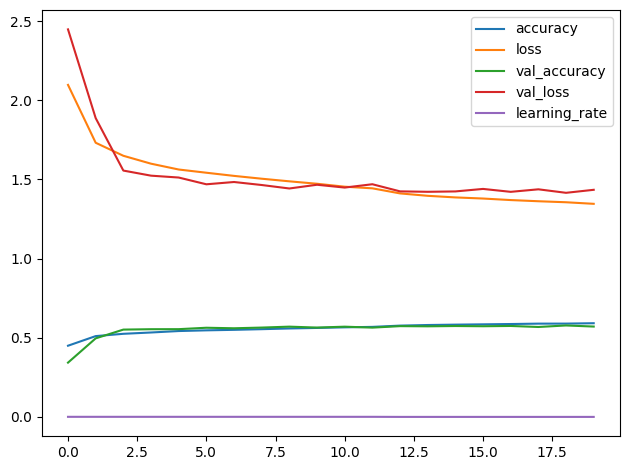

In [ ]:
plot_history(history)

In [ ]:
loss, acc = model.evaluate(graph["node_feat"][test_idx], y[test_idx], verbose=0)
acc

0.5497191548347473

In [ ]:
preds = model.predict(graph["node_feat"][test_idx])
predicted_labels = np.argmax(preds, axis=1)
nmi = normalized_mutual_info_score(y[test_idx], predicted_labels)
ari = adjusted_rand_score(y[test_idx], predicted_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
NMI: 0.3561
ARI: 0.3670


### Graph Neural Network

In [ ]:
!pip install torch_geometric --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, num_features=128, hidden_channels=256, num_classes=40):
        super(GCN, self).__init__()

        # GCNConv handles the "message passing" along the edges
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        # x shape: [num_nodes, 128]
        # edge_index shape: [2, num_edges]

        # Hop 1: Mix features with immediate neighbors
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Hop 2: Mix again and output class predictions
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN().to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Move your entire graph to the GPU
x = torch.tensor(graph["node_feat"], dtype=torch.float).to(device)
edge_index = torch.tensor(graph["edge_index"], dtype=torch.long).to(device)
y = torch.tensor(y, dtype=torch.long).squeeze().to(device)

def train():
    model.train()
    optimizer.zero_grad()

    # 1. Forward pass on the ENTIRE graph
    out = model(x, edge_index)

    # 2. Calculate loss ONLY on the training nodes
    loss = F.nll_loss(out[train_idx], y[train_idx])

    loss.backward()
    optimizer.step()
    return loss.item()

# Example training loop
for epoch in range(1, 51):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')


/tmp/ipykernel_502/2743720160.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.long).squeeze().to(device)


Epoch: 001, Loss: 3.8936
Epoch: 002, Loss: 3.1772
Epoch: 003, Loss: 3.2975
Epoch: 004, Loss: 3.0473
Epoch: 005, Loss: 3.0237
Epoch: 006, Loss: 2.9083
Epoch: 007, Loss: 2.7783
Epoch: 008, Loss: 2.7509
Epoch: 009, Loss: 2.6939
Epoch: 010, Loss: 2.5911
Epoch: 011, Loss: 2.5371
Epoch: 012, Loss: 2.4893
Epoch: 013, Loss: 2.4183
Epoch: 014, Loss: 2.3590
Epoch: 015, Loss: 2.3207
Epoch: 016, Loss: 2.2738
Epoch: 017, Loss: 2.2136
Epoch: 018, Loss: 2.1775
Epoch: 019, Loss: 2.1428
Epoch: 020, Loss: 2.1064
Epoch: 021, Loss: 2.0748
Epoch: 022, Loss: 2.0487
Epoch: 023, Loss: 2.0251
Epoch: 024, Loss: 1.9946
Epoch: 025, Loss: 1.9762
Epoch: 026, Loss: 1.9567
Epoch: 027, Loss: 1.9317
Epoch: 028, Loss: 1.9119
Epoch: 029, Loss: 1.8974
Epoch: 030, Loss: 1.8813
Epoch: 031, Loss: 1.8593
Epoch: 032, Loss: 1.8427
Epoch: 033, Loss: 1.8307
Epoch: 034, Loss: 1.8158
Epoch: 035, Loss: 1.8032
Epoch: 036, Loss: 1.7885
Epoch: 037, Loss: 1.7762
Epoch: 038, Loss: 1.7634
Epoch: 039, Loss: 1.7521
Epoch: 040, Loss: 1.7393


In [ ]:
model.eval()
out = model(x, edge_index)
pred = out.argmax(dim=1)
mask_pred = pred[test_idx].cpu().numpy()
mask_y = y[test_idx].cpu().numpy()

# 5. Calculate Metrics
correct = (mask_pred == mask_y).sum()
acc = correct / len(mask_y)
nmi = normalized_mutual_info_score(mask_y, mask_pred)
ari = adjusted_rand_score(mask_y, mask_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

Test Accuracy: 0.4364
NMI: 0.2637
ARI: 0.2474


### Keras GNN

This GNN has been provided by Khalid Salama on the Keras official website
https://keras.io/examples/graph/gnn_citations/

In [ ]:
edges = graph["edge_index"].T.T #(2, X) [0] = start nodes [1] = target nodes
edges.shape

(2, 1166243)

In [ ]:
node_features = graph["node_feat"]
node_features.shape

(169343, 128)

In [ ]:
graph_info = (node_features, edges, None)

In [ ]:
def create_gru(hidden_units, dropout_rate):
    inputs = layers.Input(shape=(2, hidden_units[0]))
    x = inputs
    for units in hidden_units:
        x = layers.GRU(
            units=units,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=True,
            dropout=dropout_rate,
        )(x)
    return keras.Model(inputs=inputs, outputs=x)

In [ ]:
def create_ffn(hidden_units, dropout_rate, name=None):
    ffn_layers = []
    for units in hidden_units:
        ffn_layers.append(layers.BatchNormalization())
        ffn_layers.append(layers.Dropout(dropout_rate))
        ffn_layers.append(layers.Dense(units, activation="gelu"))
    return keras.Sequential(ffn_layers, name=name)

In [ ]:
from keras import ops

In [ ]:
class GraphConvLayer(keras.layers.Layer):
    def __init__(
        self,
        hidden_units,
        dropout_rate=0.2,
        aggregation_type="mean",
        combination_type="concat",
        normalize=False,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        self.aggregation_type = aggregation_type
        self.combination_type = combination_type
        self.normalize = normalize

        self.ffn_prepare = create_ffn(hidden_units, dropout_rate)
        self.update_fn = (
            create_gru(hidden_units, dropout_rate)
            if combination_type == "gru"
            else create_ffn(hidden_units, dropout_rate)
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            "hidden_units": self.hidden_units,
            "dropout_rate": self.dropout_rate,
            "aggregation_type": self.aggregation_type,
            "combination_type": self.combination_type,
            "normalize": self.normalize,
        })
        return config

    def prepare(self, node_representations, weights=None, training=None):
        messages = self.ffn_prepare(node_representations, training=training)
        if weights is not None:
            messages = messages * keras.ops.expand_dims(weights, -1)
        return messages

    def aggregate(self, node_indices, neighbour_messages, node_representations):
        num_nodes = keras.ops.shape(node_representations)[0]
        if self.aggregation_type == "sum":
            return keras.ops.segment_sum(neighbour_messages, node_indices, num_segments=num_nodes)
        elif self.aggregation_type == "mean":
            return keras.ops.segment_mean(neighbour_messages, node_indices, num_segments=num_nodes)
        elif self.aggregation_type == "max":
            return keras.ops.segment_max(neighbour_messages, node_indices, num_segments=num_nodes)
        else:
            raise ValueError(f"Invalid aggregation type: {self.aggregation_type}")

    def update(self, node_representations, aggregated_messages, training=None):
        if self.combination_type == "gru":
            h = keras.ops.stack([node_representations, aggregated_messages], axis=1)
        elif self.combination_type == "concat":
            h = keras.ops.concatenate([node_representations, aggregated_messages], axis=-1)
        elif self.combination_type == "add":
            h = node_representations + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}")

        node_embeddings = self.update_fn(h, training=training)
        if self.combination_type == "gru":
            node_embeddings = keras.ops.unstack(node_embeddings, axis=1)[-1]

        if self.normalize:
            node_embeddings = keras.ops.normalize(node_embeddings, axis=-1, order=2)
        return node_embeddings

    def call(self, inputs, training=None):
        node_representations, edges, edge_weights = inputs
        node_indices, neighbour_indices = edges[0], edges[1]
        neighbour_representations = keras.ops.take(node_representations, neighbour_indices, axis=0)
        neighbour_messages = self.prepare(neighbour_representations, edge_weights, training=training)
        aggregated_messages = self.aggregate(node_indices, neighbour_messages, node_representations)
        return self.update(node_representations, aggregated_messages, training=training)

In [ ]:
class GNNNodeClassifier(keras.Model):
    def __init__(
        self,
        graph_info,
        num_classes,
        hidden_units,
        aggregation_type="sum",
        combination_type="concat",
        dropout_rate=0.5,
        normalize=True,
        add_self_loops=True,
        edge_weight_normalization="per_node",
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.graph_info = graph_info
        self.num_classes = num_classes
        self.hidden_units = hidden_units
        self.aggregation_type = aggregation_type
        self.combination_type = combination_type
        self.dropout_rate = dropout_rate
        self.normalize = normalize
        self.add_self_loops = add_self_loops
        self.edge_weight_normalization = edge_weight_normalization

        node_features, edges, edge_weights = graph_info
        num_nodes = node_features.shape[0]
        self.node_features = ops.convert_to_tensor(node_features, dtype="float32")

        if add_self_loops:
            self_loops = np.stack([np.arange(num_nodes), np.arange(num_nodes)], axis=0).astype("int32")
            edges = np.concatenate([edges, self_loops], axis=1)

        self.edges = ops.convert_to_tensor(edges, dtype="int32")
        num_edges = edges.shape[1]
        if edge_weights is None:
            edge_weights = ops.ones(shape=(num_edges,), dtype="float32")
        else:
            edge_weights = ops.convert_to_tensor(edge_weights, dtype="float32")
            if add_self_loops:
                loop_weights = ops.ones(shape=(num_nodes,), dtype="float32")
                edge_weights = ops.concatenate([edge_weights, loop_weights], axis=0)

        if edge_weight_normalization == "global":
            edge_weights = edge_weights / (ops.sum(edge_weights) + 1e-7)
        elif edge_weight_normalization == "per_node":
            node_indices = self.edges[0]
            deg = ops.segment_sum(edge_weights, node_indices, num_segments=num_nodes)
            deg = ops.maximum(deg, 1.0)
            edge_weights = edge_weights / ops.take(deg, node_indices, axis=0)

        self.edge_weights = edge_weights
        self.preprocess = create_ffn(hidden_units, dropout_rate, name="preprocess")
        self.conv1 = GraphConvLayer(hidden_units, dropout_rate=dropout_rate, aggregation_type=aggregation_type, combination_type=combination_type, normalize=normalize, name="graph_conv1")
        self.conv2 = GraphConvLayer(hidden_units, dropout_rate=dropout_rate, aggregation_type=aggregation_type, combination_type=combination_type, normalize=normalize, name="graph_conv2")
        self.postprocess = create_ffn(hidden_units, dropout_rate, name="postprocess")
        self.compute_logits = layers.Dense(num_classes, name="logits")

    def get_config(self):
        config = super().get_config()
        config.update({
            "graph_info": self.graph_info,
            "num_classes": self.num_classes,
            "hidden_units": self.hidden_units,
            "aggregation_type": self.aggregation_type,
            "combination_type": self.combination_type,
            "dropout_rate": self.dropout_rate,
            "normalize": self.normalize,
            "add_self_loops": self.add_self_loops,
            "edge_weight_normalization": self.edge_weight_normalization,
        })
        return config

    def call(self, input_node_indices, training=None):
        x = self.preprocess(self.node_features, training=training)
        x1 = self.conv1((x, self.edges, self.edge_weights), training=training)
        x = x + x1
        x2 = self.conv2((x, self.edges, self.edge_weights), training=training)
        x = x + x2
        x = self.postprocess(x, training=training)
        node_embeddings = ops.take(x, input_node_indices, axis=0)
        return self.compute_logits(node_embeddings)

In [ ]:
gnn_model = GNNNodeClassifier(
    graph_info=graph_info,
    num_classes=40,
    hidden_units=[32, 32],
    aggregation_type="sum",
    combination_type="concat",
    dropout_rate=0.5,
    normalize=True,
    add_self_loops=True,
    edge_weight_normalization="per_node",
    name="gnn_model",
)

print("GNN output shape:", gnn_model(ops.convert_to_tensor([0, 1, 2], dtype="int32")))

gnn_model.summary()

GNN output shape: tf.Tensor(
[[-1.02181114e-01 -3.95856798e-02  4.43049930e-02  5.99417761e-02
  -1.06309764e-01  1.42803401e-01 -1.63956545e-03 -1.25803873e-02
   6.86971992e-02  8.20810720e-02 -1.22182749e-01  2.76870653e-03
   2.14444786e-01 -4.76289541e-04 -4.92827818e-02  3.74999829e-02
   1.23773202e-01  3.59232128e-02  4.24808487e-02 -3.89936380e-02
  -1.51130781e-02 -1.14580430e-02  1.79102384e-02 -1.41853511e-01
   9.48882028e-02 -5.00465147e-02 -5.85253611e-02 -5.64650223e-02
   3.18572186e-02 -8.86256844e-02  2.26776842e-02  7.52355084e-02
   6.98353276e-02 -2.04278529e-03 -1.52758077e-01  6.25958666e-04
   6.82705045e-02  2.72555389e-02 -1.24318637e-01  8.48359987e-03]
 [-5.81667423e-02 -4.64650132e-02  2.29413044e-02  3.94695029e-02
  -8.87189955e-02  1.38787344e-01  1.49230473e-04 -1.33426059e-02
   5.62942587e-02  2.64934711e-02 -1.14862986e-01  4.09754962e-02
   1.74789920e-01 -5.21402396e-02 -8.26804042e-02  4.62644547e-02
   1.06955260e-01  1.57890655e-02  5.29693663e

Model: "gnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocess (Sequential)         │ (169343, 32)           │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv1 (GraphConvLayer)    │ ?                      │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv2 (GraphConvLayer)    │ ?                      │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ postprocess (Sequential)        │ (169343, 32)           │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (3, 40)                │         1,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,288 (83.16 KB)

 Trainable params: 20,200 (78.91 KB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
gnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
    )

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=50,
        restore_best_weights=True,
    )

history = gnn_model.fit(
      x=train_idx,
      y=y[train_idx],
      validation_data=(valid_idx, y[valid_idx]),
      epochs=300,
      batch_size=256,
      callbacks=[early_stopping],
      verbose=2,
  )

Epoch 1/300
356/356 - 72s - 202ms/step - acc: 0.4133 - loss: 2.1609 - val_acc: 0.5576 - val_loss: 1.6078
Epoch 2/300
356/356 - 43s - 121ms/step - acc: 0.4156 - loss: 2.1519 - val_acc: 0.5562 - val_loss: 1.6374
Epoch 3/300
356/356 - 42s - 119ms/step - acc: 0.4169 - loss: 2.1532 - val_acc: 0.5467 - val_loss: 1.6451
Epoch 4/300
356/356 - 42s - 119ms/step - acc: 0.4193 - loss: 2.1429 - val_acc: 0.5485 - val_loss: 1.6394
Epoch 5/300
356/356 - 42s - 119ms/step - acc: 0.4172 - loss: 2.1379 - val_acc: 0.5602 - val_loss: 1.6142
Epoch 6/300
356/356 - 42s - 119ms/step - acc: 0.4180 - loss: 2.1356 - val_acc: 0.5471 - val_loss: 1.6470
Epoch 7/300
356/356 - 42s - 119ms/step - acc: 0.4201 - loss: 2.1354 - val_acc: 0.5627 - val_loss: 1.6055
Epoch 8/300
356/356 - 42s - 118ms/step - acc: 0.4203 - loss: 2.1343 - val_acc: 0.5510 - val_loss: 1.6253
Epoch 9/300
356/356 - 42s - 118ms/step - acc: 0.4239 - loss: 2.1300 - val_acc: 0.5517 - val_loss: 1.6090
Epoch 10/300
356/356 - 42s - 119ms/step - acc: 0.4223 -

In [ ]:
preds = gnn_model.predict(test_idx)

1519/1519 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step


In [ ]:
preds.shape

(48603, 40)

In [ ]:
predicted_labels = np.argmax(preds, axis=1)
nmi = normalized_mutual_info_score(y[test_idx], predicted_labels)
ari = adjusted_rand_score(y[test_idx], predicted_labels)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.4456
ARI: 0.4692


In [ ]:
gnn_model.save_weights("Keras_GNN_Model.weights.h5")

In [ ]:
import pickle
with open("Keras_Preds", "wb+") as f:
    pickle.dump(preds, f)

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Extract numpy features
X_train_np = graph["node_feat"][train_idx]
y_train_np = y[train_idx]
X_test_np = graph["node_feat"][test_idx]
y_test_np = y[test_idx]

# 2. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

# 3. Fit Logistic Regression
# 'multinomial' handles the 40 classes, 'lbfgs' is a fast solver
print("Training Logistic Regression model...")
clf = LogisticRegression(solver='lbfgs', max_iter=500, verbose=1)
clf.fit(X_train_scaled, y_train_np)

# 4. Evaluate
score = clf.score(X_test_scaled, y_test_np)
print(f"\nLogistic Regression Test Accuracy: {score:.4f}")

Training Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.6min finished



Logistic Regression Test Accuracy: 0.5244


In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

In [ ]:
y_true = y[test_idx]

nmi = normalized_mutual_info_score(y_true, preds)
ari = adjusted_rand_score(y_true, preds)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.2210
ARI: 0.1268
